In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 31 / e_mass      # now in a.u.
c6 = 5.2e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 56509.54307916515
C6 520000.0
beta (a0) 492.36682576656693
E_beta (K) 11.525197727053389
tau_beta (s) 4.164130464303455e-06


In [15]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 6e-5     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.2         # in terms of E6
num_resonances = 400        # should be odd
print(temp * 58 / mean_spacing)

0.06940217440505757
167.14173726457005


In [16]:
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [20]:
energy_grid = np.linspace(0, 2 * temp, 10000)[1:]

In [6]:
S1 = []
for collision_energy in energy_grid:
    D = np.diag(collision_energy - energy_GOE_mat) + 1j * np.pi * np.outer(W_mat, W_mat)
    S = 1 - 2j * np.pi * np.inner(W_mat, np.linalg.inv(D) @ W_mat)
    S1.append(S)

KeyboardInterrupt: 

In [31]:
S2 = []
for collision_energy in energy_grid:
    K = np.pi * np.inner(W_mat, W_mat / (collision_energy - energy_GOE_mat))
    S = (1 - 1j * K) / (1 + 1j * K)
    S2.append(S)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


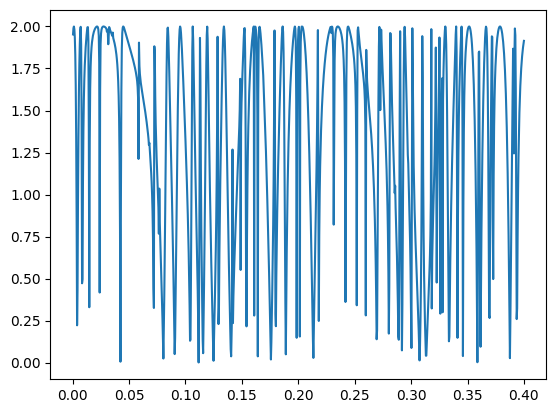

In [34]:
plt.plot(energy_grid, np.abs(1-np.array(S1)))
print(np.abs(np.array(S1))[:10])

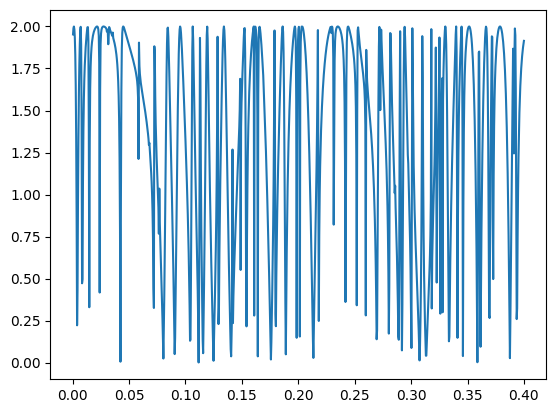

In [32]:
plt.plot(energy_grid, np.abs(1-np.array(S2)))

(0.0, 0.01)

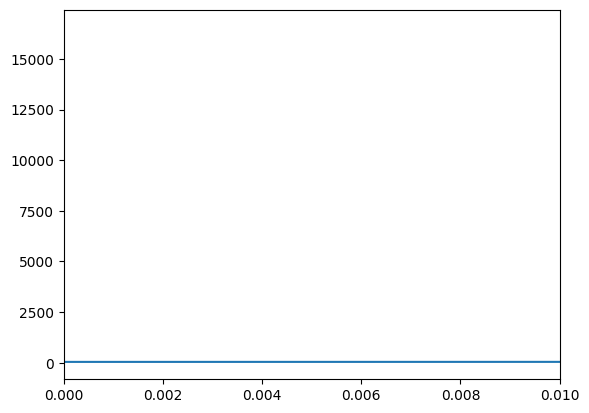

In [ ]:
Q = []
for collision_energy in energy_grid:
    K = -np.pi * np.inner(W_mat, W_mat / (collision_energy - energy_GOE_mat))
    K_p = np.pi * np.inner(W_mat, W_mat / (collision_energy - energy_GOE_mat) ** 2)
    Q.append(2 * K_p / (1 + K ** 2))

plt.plot(energy_grid, Q)
plt.xlim(0, 0.01)
plt.ylim()